<a href="https://colab.research.google.com/github/narendrapatel6321-dotcom/ZomatoDeliveryTimePrediction/blob/main/03AnalysisAndUncertanity_zd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Zomato Delivery Time Prediction — 03: Analysis, Explainability & Uncertainty

Covers: feature importance (native + permutation), SHAP, residual analysis, error segmentation,
quantile regression / prediction intervals, predict_delivery(), temporal generalization,
case studies. Final model choice (XGBoost vs HistGB) made here based on diagnostics, not just MAE.

In [1]:
!git clone https://github.com/narendrapatel6321-dotcom/ZomatoDeliveryTimePrediction.git
import sys
sys.path.append("/content/ZomatoDeliveryTimePrediction/src")

Cloning into 'ZomatoDeliveryTimePrediction'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 19 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 961.60 KiB | 5.53 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DRIVE_OUTPUT_DIR = "/content/drive/MyDrive/zomato-delivery-time-prediction"

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

Mounted at /content/drive


In [3]:
df = pd.read_parquet(f"{DRIVE_OUTPUT_DIR}/prepared_data.parquet")

with open(f"{DRIVE_OUTPUT_DIR}/feature_metadata.json") as f:
    feature_metadata = json.load(f)

with open(f"{DRIVE_OUTPUT_DIR}/modeling_metadata.json") as f:
    modeling_metadata = json.load(f)

with open(f"{DRIVE_OUTPUT_DIR}/models/tuned_candidates.pkl", "rb") as f:
    tuned_candidates = pickle.load(f)

target_col = feature_metadata["target_col"]

print("Loaded prepared data:", df.shape)
print("Tuned candidates:", list(tuned_candidates.keys()))
print("\nModeling decisions from notebook 2:")
print(json.dumps(modeling_metadata, indent=2))

Loaded prepared data: (45584, 36)
Tuned candidates: ['XGBoost (tuned)', 'HistGB (tuned)']

Modeling decisions from notebook 2:
{
  "final_feature_groups": "raw + geographic + temporal (no interaction terms \u2014 see ablation)",
  "excluded_interaction_features": [
    "traffic_severity",
    "distance_x_traffic",
    "weather_bad",
    "distance_x_weather_bad"
  ],
  "models_dropped_from_tuning": [
    "Random Forest \u2014 tied top MAE, ~20x slower to train"
  ],
  "xgb_best_params": {
    "n_estimators": 491,
    "max_depth": 10,
    "learning_rate": 0.01797343955251045,
    "min_child_weight": 2,
    "subsample": 0.8244563609172214,
    "colsample_bytree": 0.8561714454419305,
    "reg_alpha": 0.006129358552529108,
    "reg_lambda": 2.732392881504184,
    "gamma": 0.013055171512827313
  },
  "xgb_best_val_mae": 3.158237934112549,
  "histgb_best_params": {
    "max_iter": 628,
    "max_depth": 15,
    "learning_rate": 0.0604064471721583,
    "max_leaf_nodes": 117,
    "min_samples_le

In [4]:
train_df = df[df["split_random"] == "train"].copy()
val_df = df[df["split_random"] == "val"].copy()
test_df = df[df["split_random"] == "test"].copy()

X_train, y_train = train_df, train_df[target_col]
X_val, y_val = val_df, val_df[target_col]
X_test, y_test = test_df, test_df[target_col]

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)} (test still untouched)")

Train: 31908, Val: 6838, Test: 6838 (test still untouched)


In [5]:
from eval_utils import compute_metrics

xgb_model = tuned_candidates["XGBoost (tuned)"]
histgb_model = tuned_candidates["HistGB (tuned)"]

xgb_val_mae = compute_metrics(y_val, xgb_model.predict(X_val))["MAE"]
histgb_val_mae = compute_metrics(y_val, histgb_model.predict(X_val))["MAE"]

print(f"XGBoost val MAE now: {xgb_val_mae:.4f} (expected ~{modeling_metadata['xgb_best_val_mae']:.4f})")
print(f"HistGB val MAE now:  {histgb_val_mae:.4f} (expected ~{modeling_metadata['histgb_best_val_mae']:.4f})")

XGBoost val MAE now: 3.1582 (expected ~3.1582)
HistGB val MAE now:  3.1597 (expected ~3.1597)


## Global Feature Importance — Native + Permutation

Native importance first (fast, model-specific), then permutation importance (slower, model-agnostic,
per plan Section 17 — preferred for a fair cross-model view since native importance methods differ
between XGBoost and HistGB internally).

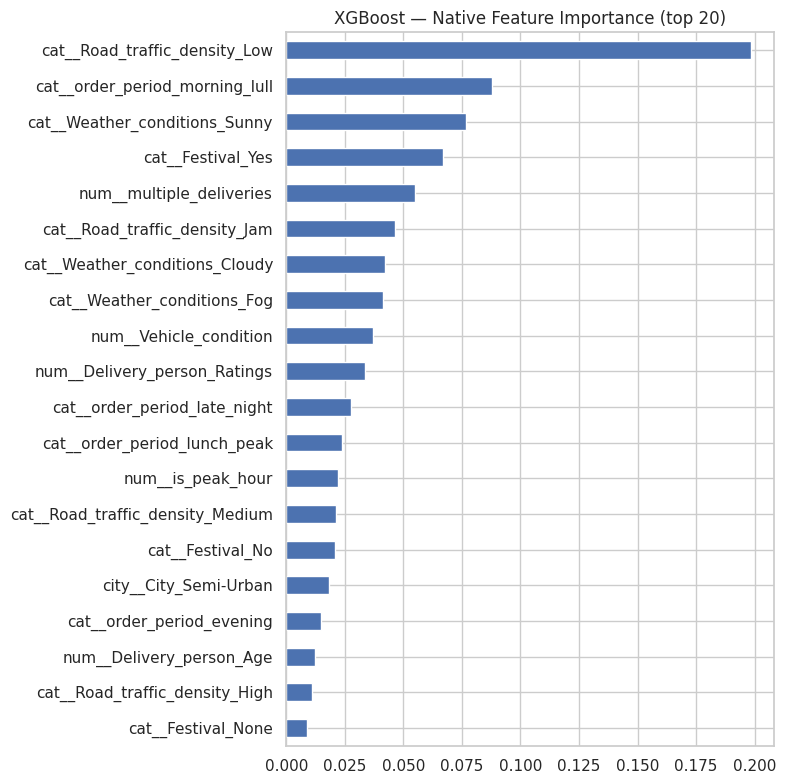

In [6]:
def get_feature_names(pipeline):
    """Pull final one-hot/expanded feature names out of the fitted ColumnTransformer."""
    return pipeline.named_steps["preprocess"].get_feature_names_out()

xgb_feature_names = get_feature_names(xgb_model)
histgb_native_importance = None  # HistGB has no native feature_importances_ — permutation only

xgb_importance = pd.Series(
    xgb_model.named_steps["model"].feature_importances_, index=xgb_feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
xgb_importance.head(20).sort_values().plot(kind="barh", ax=ax)
ax.set_title("XGBoost — Native Feature Importance (top 20)")
plt.tight_layout()
plt.show()

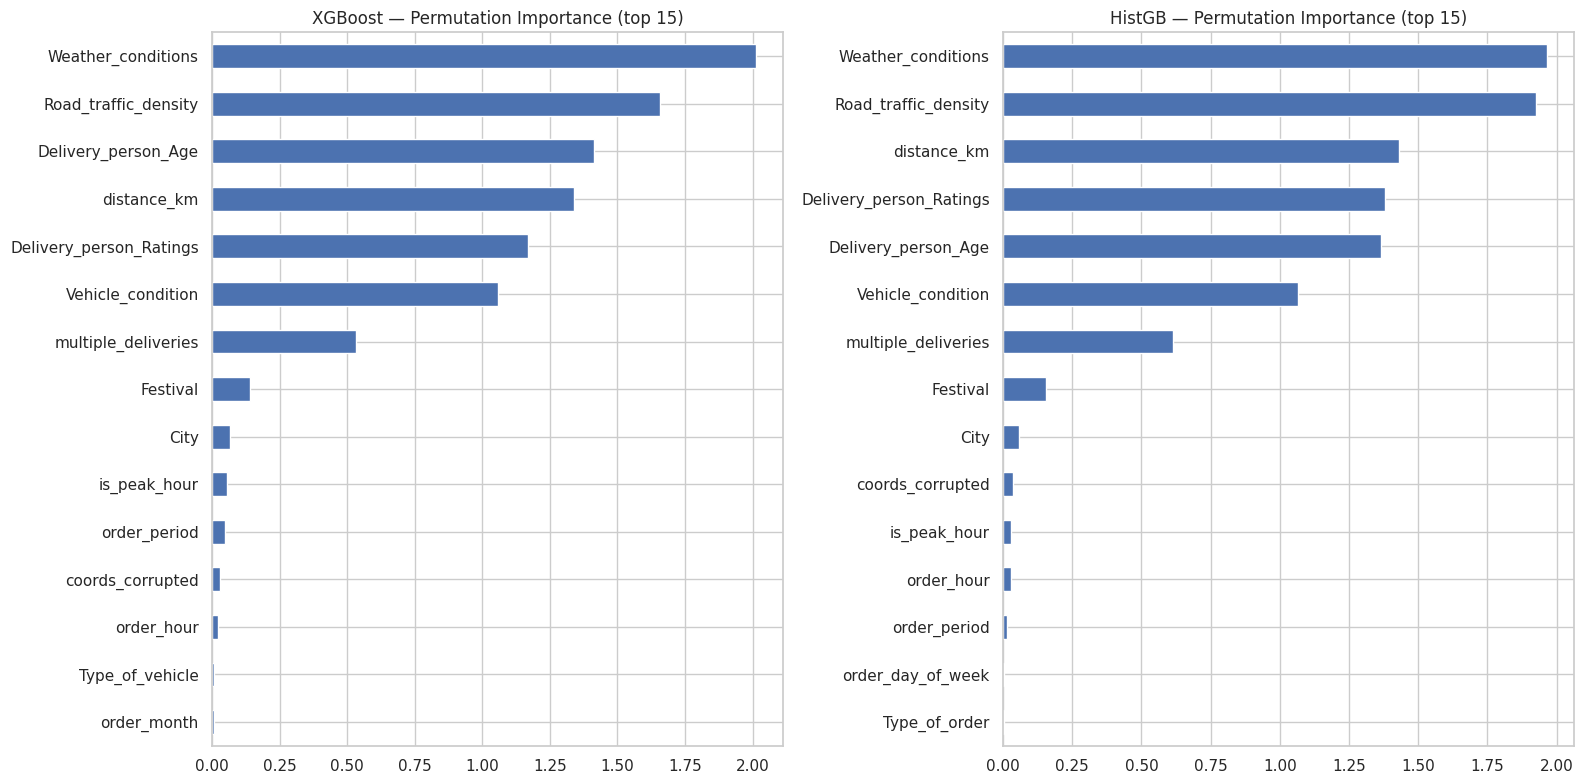

In [7]:
from sklearn.inspection import permutation_importance

perm_xgb = permutation_importance(
    xgb_model, X_val, y_val, n_repeats=10, random_state=RANDOM_SEED, scoring="neg_mean_absolute_error", n_jobs=-1
)
perm_histgb = permutation_importance(
    histgb_model, X_val, y_val, n_repeats=10, random_state=RANDOM_SEED, scoring="neg_mean_absolute_error", n_jobs=-1
)

# permutation_importance runs on the ORIGINAL columns (X_val), not the expanded one-hot columns —
# more interpretable, since it tells us "how much does dropping this raw column hurt", not
# "how much does dropping this one dummy-encoded level hurt"
perm_xgb_series = pd.Series(perm_xgb.importances_mean, index=X_val.columns).sort_values(ascending=False)
perm_histgb_series = pd.Series(perm_histgb.importances_mean, index=X_val.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
perm_xgb_series.head(15).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("XGBoost — Permutation Importance (top 15)")

perm_histgb_series.head(15).sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("HistGB — Permutation Importance (top 15)")
plt.tight_layout()
plt.show()

## SHAP — Global Importance and Dependence

Resolves the permutation-vs-native disagreement on Festival by looking at per-instance effects.
Also used to examine the shape of the Age relationship (positive correlation direction was
unexpected in notebook 1 — is it linear, threshold-based, or an interaction artifact?).

In [8]:
!pip install shap --quiet
import shap

# TreeExplainer works directly on the underlying booster/model, so we explain in the
# *transformed* (preprocessed) feature space — need the transformed X and matching feature names
X_val_transformed_xgb = xgb_model.named_steps["preprocess"].transform(X_val)
X_val_transformed_histgb = histgb_model.named_steps["preprocess"].transform(X_val)

xgb_feature_names = xgb_model.named_steps["preprocess"].get_feature_names_out()
histgb_feature_names = histgb_model.named_steps["preprocess"].get_feature_names_out()

explainer_xgb = shap.TreeExplainer(xgb_model.named_steps["model"])
explainer_histgb = shap.TreeExplainer(histgb_model.named_steps["model"])

# Sample for speed — SHAP on the full val set is slow; 2000 rows is plenty for stable global patterns
sample_idx = np.random.RandomState(RANDOM_SEED).choice(len(X_val), size=2000, replace=False)

X_sample_xgb = X_val_transformed_xgb[sample_idx]
X_sample_histgb = X_val_transformed_histgb[sample_idx]

shap_values_xgb = explainer_xgb.shap_values(X_sample_xgb)
shap_values_histgb = explainer_histgb.shap_values(X_sample_histgb)

print("SHAP values computed for both models")

SHAP values computed for both models


/tmp/ipykernel_977/4167493857.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_xgb, X_sample_xgb_df, max_display=20, show=False)


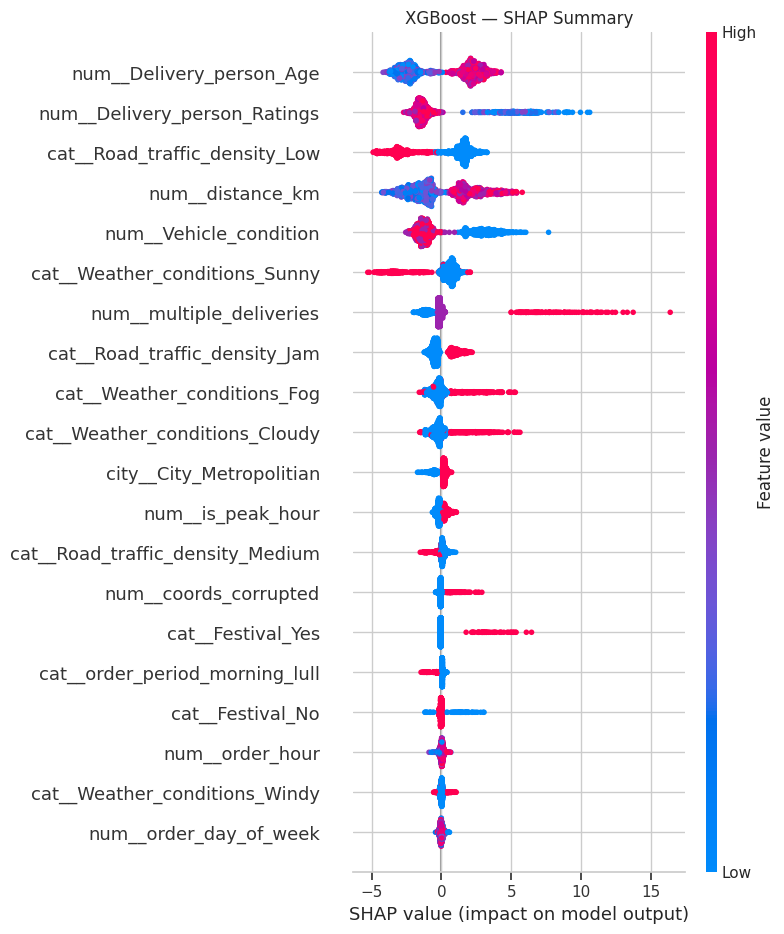

/tmp/ipykernel_977/4167493857.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_histgb, X_sample_histgb_df, max_display=20, show=False)


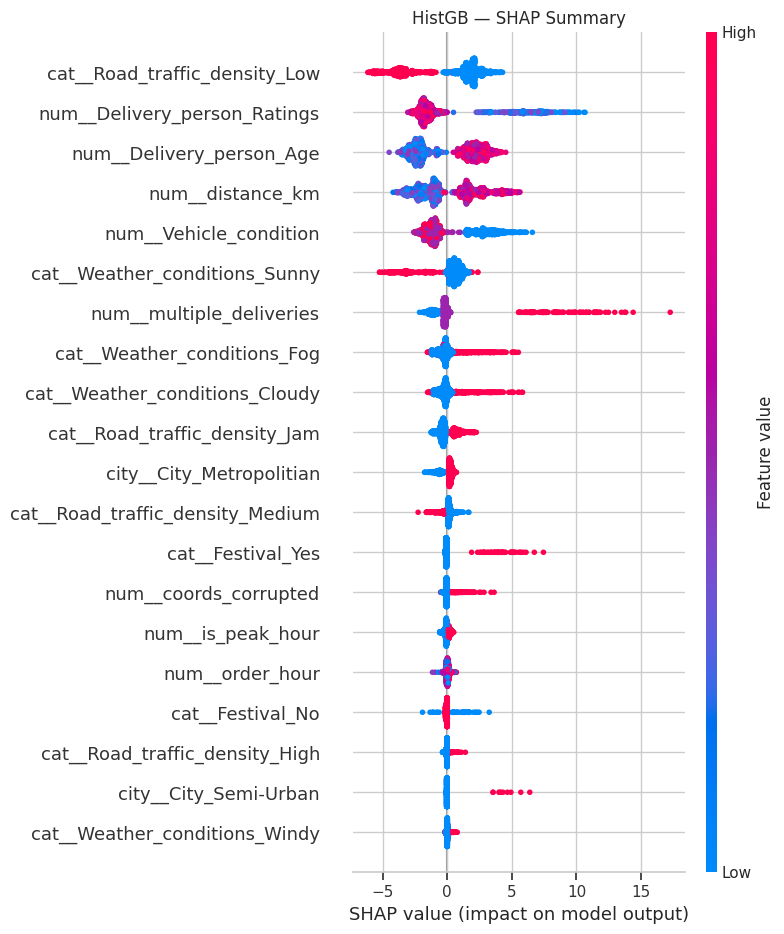

In [9]:
import pandas as pd

X_sample_xgb_df = pd.DataFrame(X_sample_xgb, columns=xgb_feature_names)
X_sample_histgb_df = pd.DataFrame(X_sample_histgb, columns=histgb_feature_names)

shap.summary_plot(shap_values_xgb, X_sample_xgb_df, max_display=20, show=False)
plt.title("XGBoost — SHAP Summary")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values_histgb, X_sample_histgb_df, max_display=20, show=False)
plt.title("HistGB — SHAP Summary")
plt.tight_layout()
plt.show()

Festival-related columns: ['cat__Festival_No', 'cat__Festival_Yes', 'cat__Festival_None']


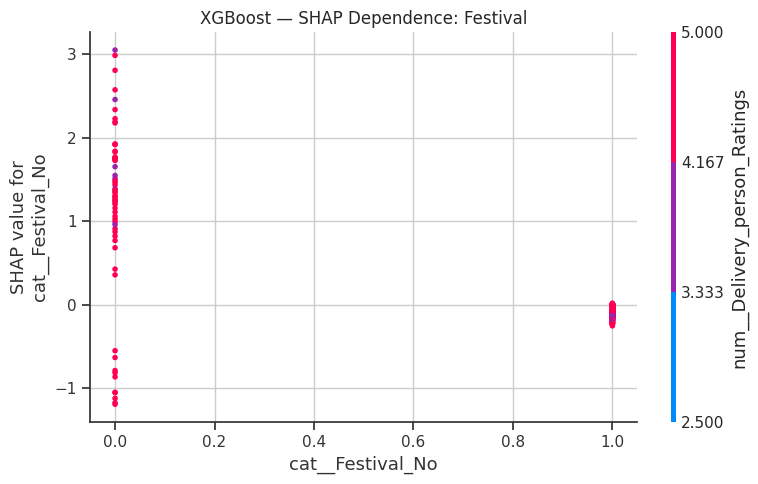

In [10]:
festival_col = [c for c in xgb_feature_names if "Festival" in c]
print(f"Festival-related columns: {festival_col}")

fig, ax = plt.subplots(figsize=(8, 5))
shap.dependence_plot(festival_col[0], shap_values_xgb, X_sample_xgb_df, ax=ax, show=False)
ax.set_title("XGBoost — SHAP Dependence: Festival")
plt.tight_layout()
plt.show()

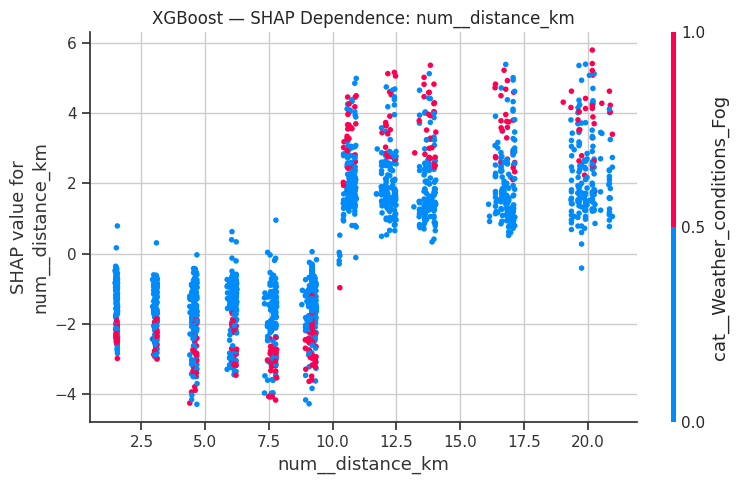

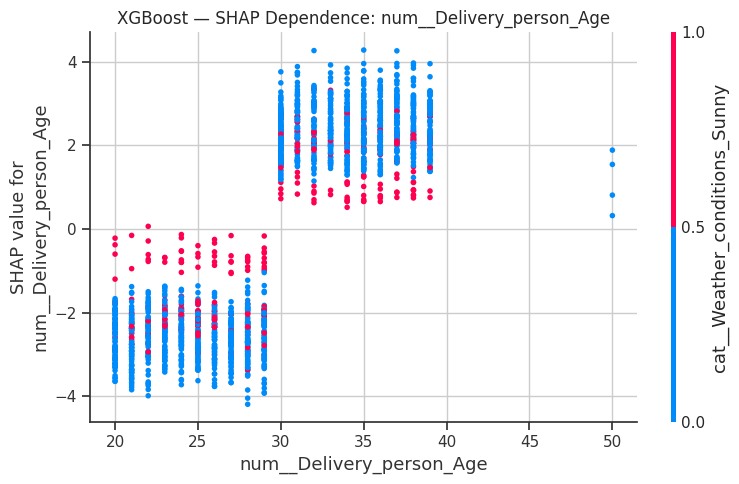

In [11]:
for feat in ["num__distance_km", "num__Delivery_person_Age"]:
    fig, ax = plt.subplots(figsize=(8, 5))
    shap.dependence_plot(feat, shap_values_xgb, X_sample_xgb_df, ax=ax, show=False)
    ax.set_title(f"XGBoost — SHAP Dependence: {feat}")
    plt.tight_layout()
    plt.show()

## Residual Analysis

residual = actual - predicted. Positive residual = model underpredicted (actual took longer than
expected). Both models compared side by side to look for the tiebreaker MAE alone couldn't give us.

In [12]:
val_df["pred_xgb"] = xgb_model.predict(X_val)
val_df["pred_histgb"] = histgb_model.predict(X_val)

val_df["residual_xgb"] = val_df[target_col] - val_df["pred_xgb"]
val_df["residual_histgb"] = val_df[target_col] - val_df["pred_histgb"]

print(val_df[["residual_xgb", "residual_histgb"]].describe())

       residual_xgb  residual_histgb
count   6838.000000      6838.000000
mean       0.003897         0.020604
std        3.971372         3.970947
min      -14.335730       -16.963686
25%       -2.789454        -2.782506
50%       -0.125906        -0.129606
75%        2.597826         2.614852
max       24.304991        20.672017


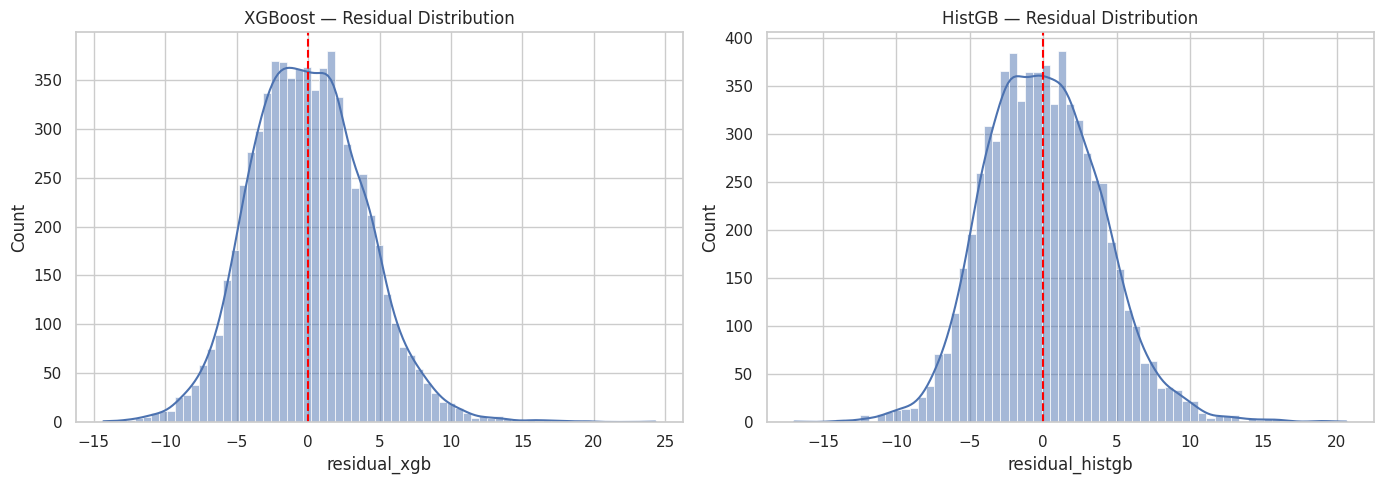

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(val_df["residual_xgb"], kde=True, ax=axes[0])
axes[0].axvline(0, color="red", linestyle="--")
axes[0].set_title("XGBoost — Residual Distribution")

sns.histplot(val_df["residual_histgb"], kde=True, ax=axes[1])
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("HistGB — Residual Distribution")
plt.tight_layout()
plt.show()

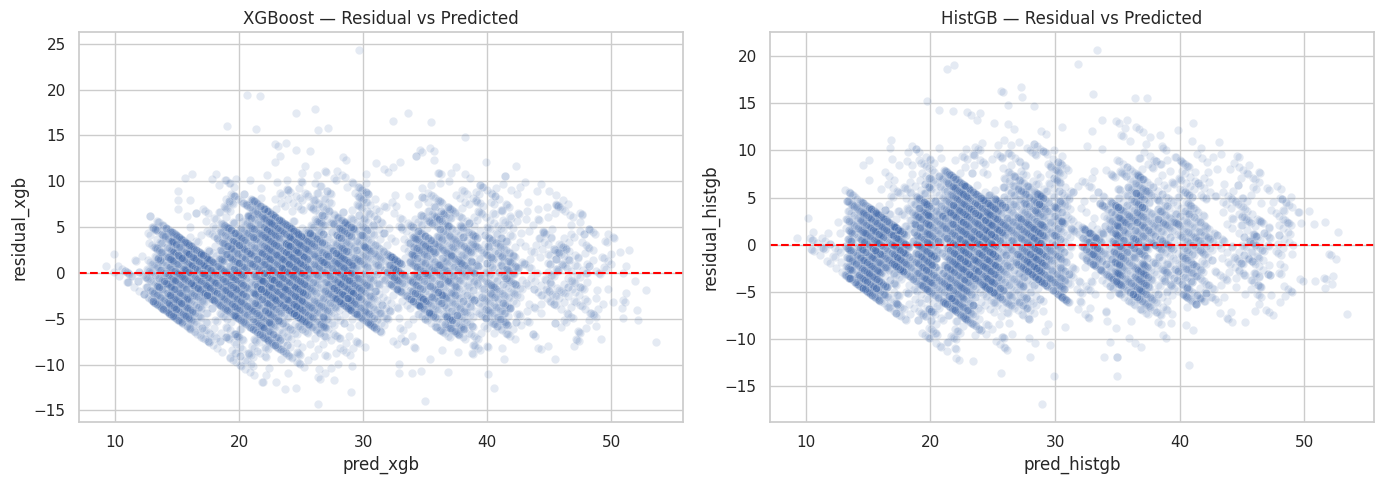

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=val_df["pred_xgb"], y=val_df["residual_xgb"], alpha=0.15, ax=axes[0])
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("XGBoost — Residual vs Predicted")

sns.scatterplot(x=val_df["pred_histgb"], y=val_df["residual_histgb"], alpha=0.15, ax=axes[1])
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("HistGB — Residual vs Predicted")
plt.tight_layout()
plt.show()

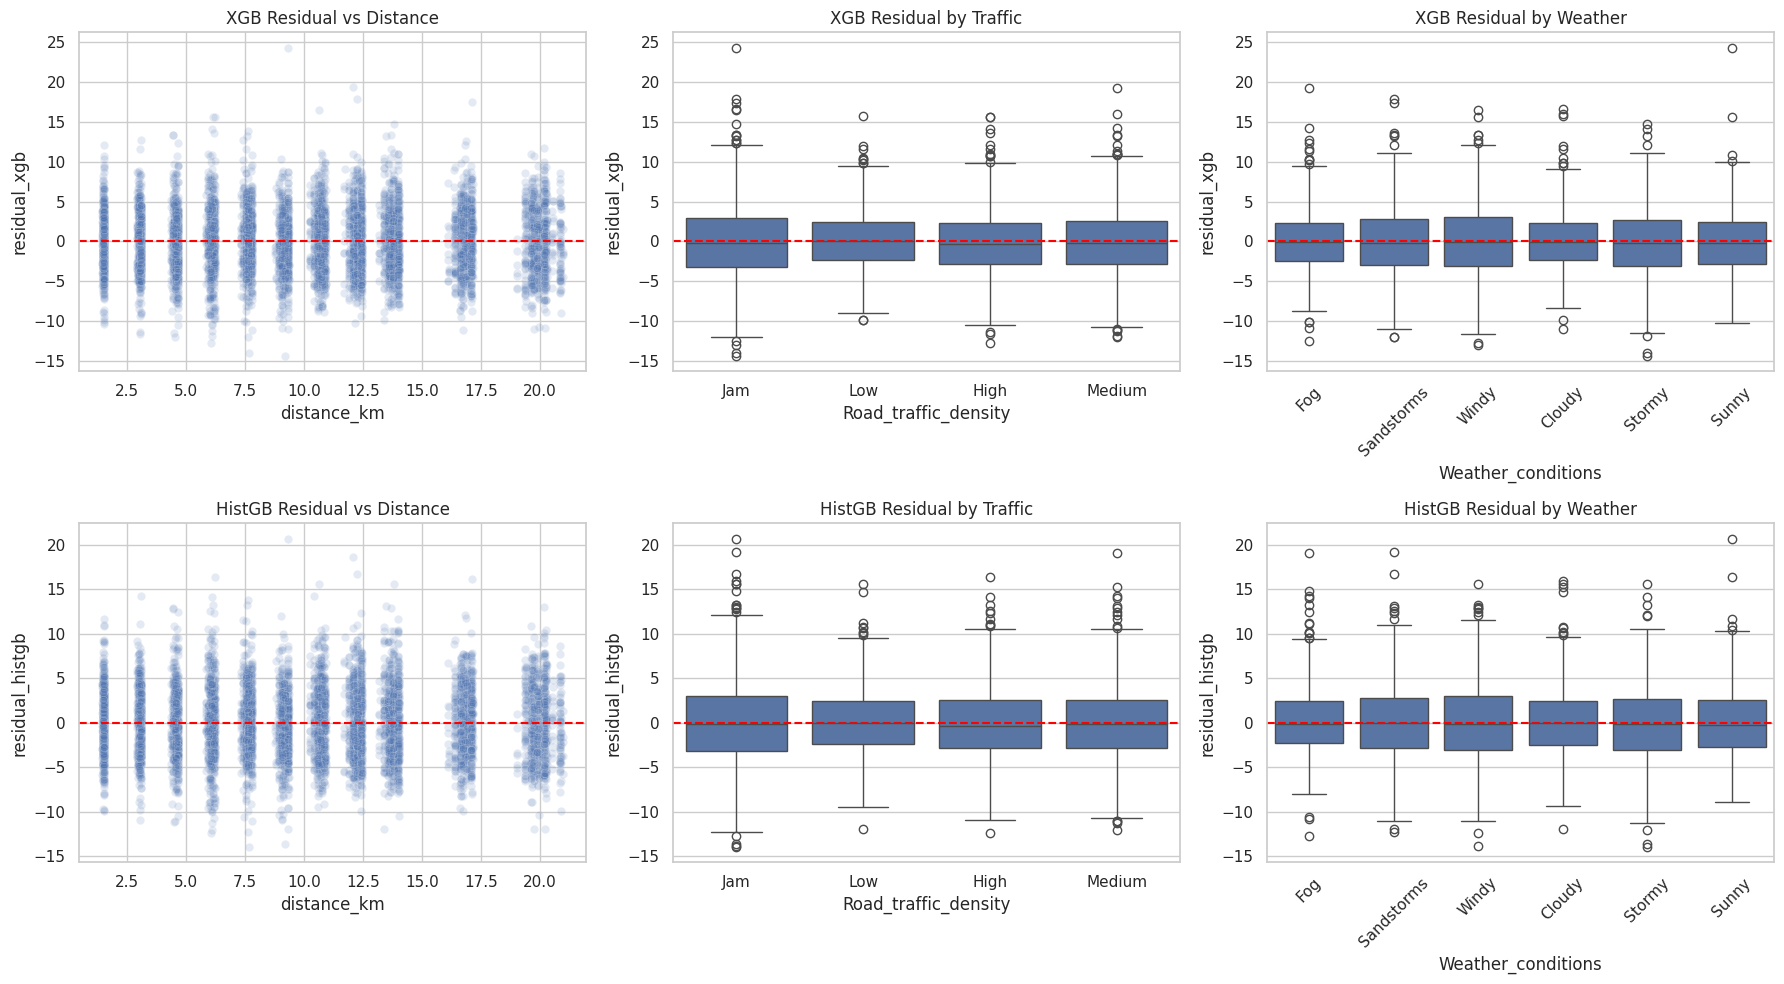

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.scatterplot(x=val_df["distance_km"], y=val_df["residual_xgb"], alpha=0.15, ax=axes[0, 0])
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("XGB Residual vs Distance")

sns.boxplot(data=val_df, x="Road_traffic_density", y="residual_xgb", ax=axes[0, 1])
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_title("XGB Residual by Traffic")

sns.boxplot(data=val_df, x="Weather_conditions", y="residual_xgb", ax=axes[0, 2])
axes[0, 2].axhline(0, color="red", linestyle="--")
axes[0, 2].set_title("XGB Residual by Weather")
axes[0, 2].tick_params(axis="x", rotation=45)

sns.scatterplot(x=val_df["distance_km"], y=val_df["residual_histgb"], alpha=0.15, ax=axes[1, 0])
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_title("HistGB Residual vs Distance")

sns.boxplot(data=val_df, x="Road_traffic_density", y="residual_histgb", ax=axes[1, 1])
axes[1, 1].axhline(0, color="red", linestyle="--")
axes[1, 1].set_title("HistGB Residual by Traffic")

sns.boxplot(data=val_df, x="Weather_conditions", y="residual_histgb", ax=axes[1, 2])
axes[1, 2].axhline(0, color="red", linestyle="--")
axes[1, 2].set_title("HistGB Residual by Weather")
axes[1, 2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

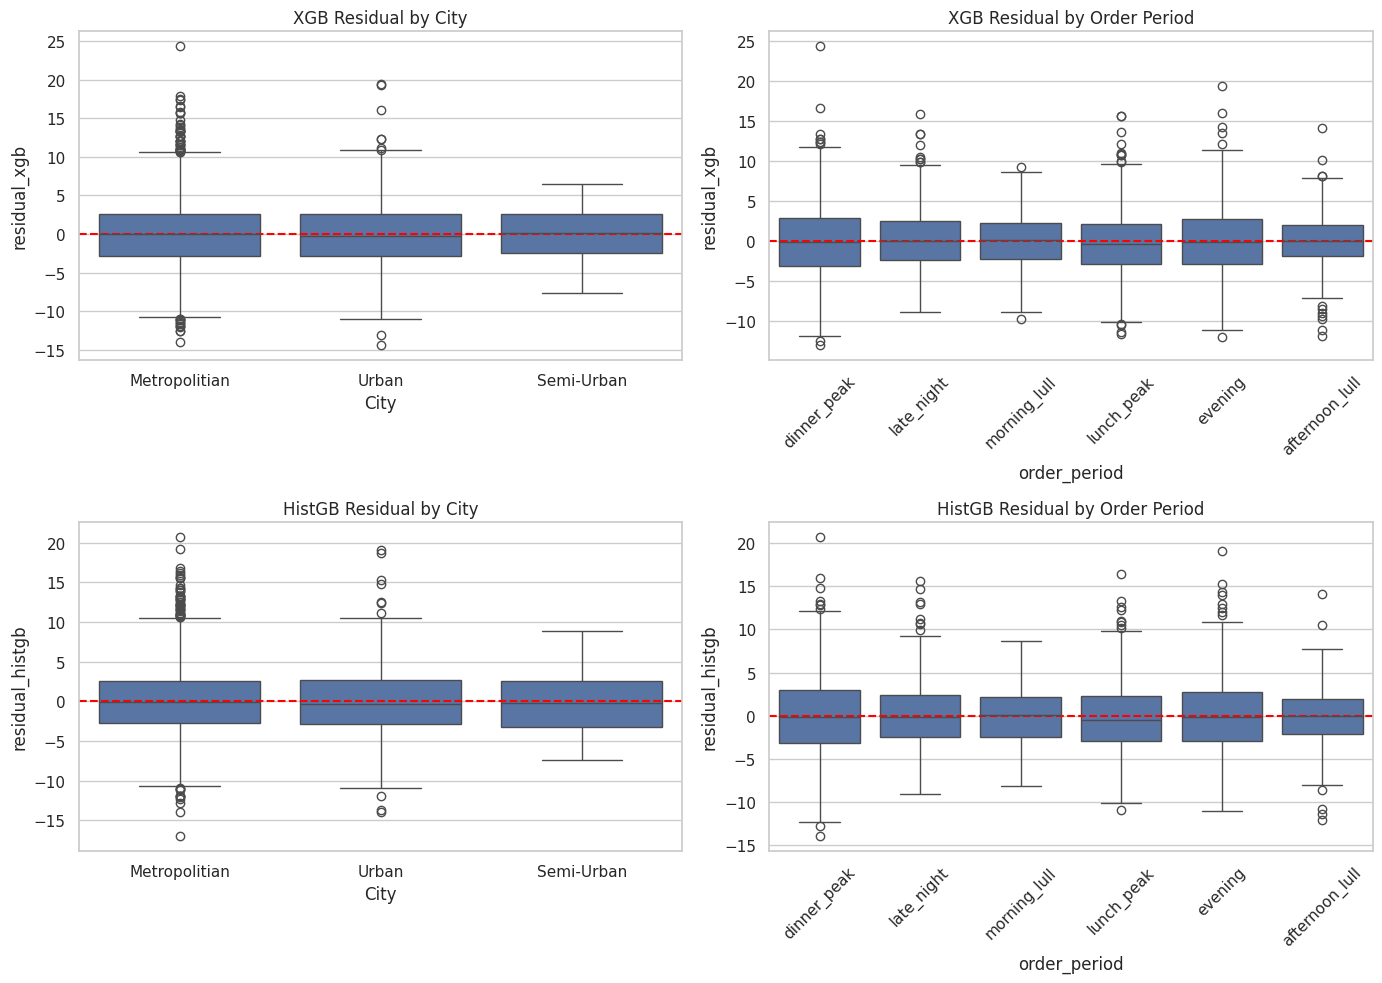

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(data=val_df, x="City", y="residual_xgb", ax=axes[0, 0])
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("XGB Residual by City")

sns.boxplot(data=val_df, x="order_period", y="residual_xgb", ax=axes[0, 1])
axes[0, 1].axhline(0, color="red", linestyle="--")
axes[0, 1].set_title("XGB Residual by Order Period")
axes[0, 1].tick_params(axis="x", rotation=45)

sns.boxplot(data=val_df, x="City", y="residual_histgb", ax=axes[1, 0])
axes[1, 0].axhline(0, color="red", linestyle="--")
axes[1, 0].set_title("HistGB Residual by City")

sns.boxplot(data=val_df, x="order_period", y="residual_histgb", ax=axes[1, 1])
axes[1, 1].axhline(0, color="red", linestyle="--")
axes[1, 1].set_title("HistGB Residual by Order Period")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Error Segmentation — Numeric Tables

Boxplots showed no visual bias, but the two models are close enough that we need per-segment MAE
numbers, not eyeballed box plots, to find a real tiebreaker.

In [17]:
import importlib
import eval_utils
importlib.reload(eval_utils)
from eval_utils import segment_mae_table

In [18]:
pred_cols = {"XGB": "pred_xgb", "HistGB": "pred_histgb"}

for seg_col in ["Road_traffic_density", "Weather_conditions", "City", "order_period"]:
    table = segment_mae_table(val_df, seg_col, target_col, pred_cols)
    table["XGB_wins"] = table["MAE_XGB"] < table["MAE_HistGB"]
    print(f"--- {seg_col} ---")
    print(table)
    print()

--- Road_traffic_density ---
  Road_traffic_density  count   MAE_XGB  MAE_HistGB  XGB_wins
0                 High    671  3.312077    3.383789      True
1                  Jam   2120  3.535271    3.524279     False
2                  Low   2381  2.669390    2.687825      True
3               Medium   1580  3.176741    3.122381     False

--- Weather_conditions ---
  Weather_conditions  count   MAE_XGB  MAE_HistGB  XGB_wins
0             Cloudy   1120  2.818787    2.823144      True
1                Fog   1141  2.873971    2.875349      True
2         Sandstorms   1144  3.349943    3.346015     False
3             Stormy   1132  3.321242    3.304254     False
4              Sunny   1060  2.910148    2.938575      True
5              Windy   1154  3.442894    3.417057     False

--- City ---
            City  count   MAE_XGB  MAE_HistGB  XGB_wins
0  Metropolitian   5163  3.157587    3.142558     False
1     Semi-Urban     26  2.957317    3.129542      True
2          Urban   1460  3.1751

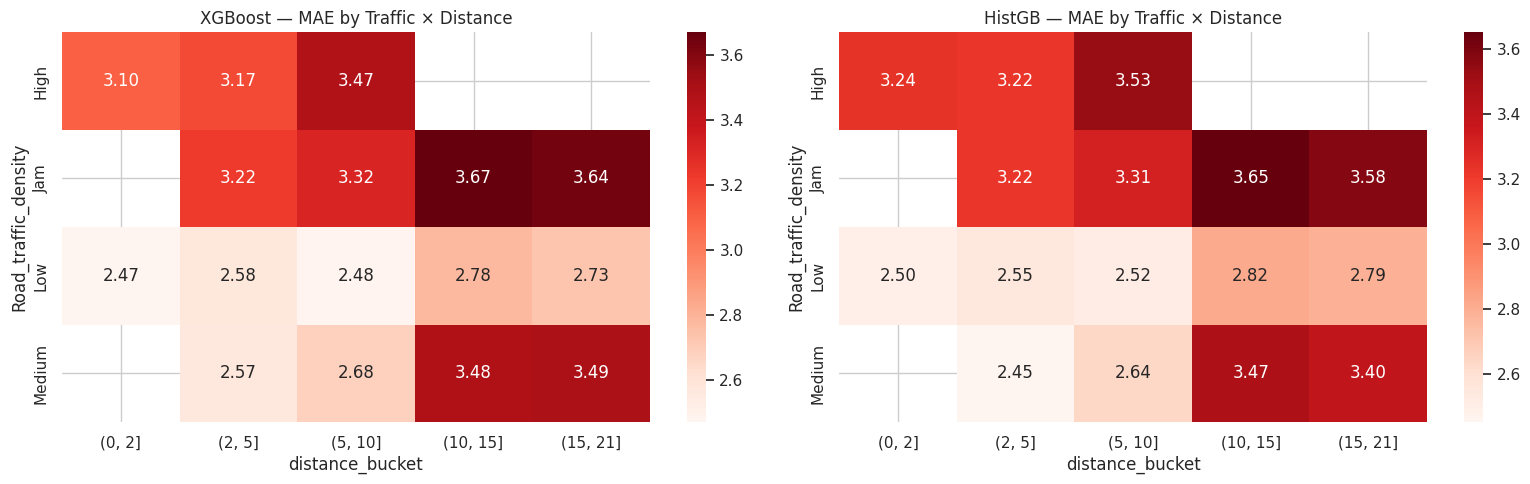

In [19]:
val_df["distance_bucket"] = pd.cut(val_df["distance_km"], bins=[0, 2, 5, 10, 15, 21])

pivot_xgb = val_df.pivot_table(
    values="residual_xgb", index="Road_traffic_density", columns="distance_bucket",
    aggfunc=lambda x: x.abs().mean(), observed=True
)
pivot_histgb = val_df.pivot_table(
    values="residual_histgb", index="Road_traffic_density", columns="distance_bucket",
    aggfunc=lambda x: x.abs().mean(), observed=True
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(pivot_xgb, annot=True, fmt=".2f", cmap="Reds", ax=axes[0])
axes[0].set_title("XGBoost — MAE by Traffic × Distance")

sns.heatmap(pivot_histgb, annot=True, fmt=".2f", cmap="Reds", ax=axes[1])
axes[1].set_title("HistGB — MAE by Traffic × Distance")
plt.tight_layout()
plt.show()

In [20]:
all_segment_results = []
for seg_col in ["Road_traffic_density", "Weather_conditions", "City", "order_period"]:
    table = segment_mae_table(val_df, seg_col, target_col, pred_cols)
    all_segment_results.append(table)

combined = pd.concat(all_segment_results, ignore_index=True)
print(f"XGBoost wins (lower MAE) in {(combined['MAE_XGB'] < combined['MAE_HistGB']).sum()} / {len(combined)} segments")
print(f"HistGB wins (lower MAE) in {(combined['MAE_HistGB'] < combined['MAE_XGB']).sum()} / {len(combined)} segments")
print(f"\nWorst-case (max) segment MAE — XGB: {combined['MAE_XGB'].max():.3f}, HistGB: {combined['MAE_HistGB'].max():.3f}")
print(f"Mean |MAE_XGB - MAE_HistGB| across segments: {(combined['MAE_XGB'] - combined['MAE_HistGB']).abs().mean():.4f}")

XGBoost wins (lower MAE) in 10 / 19 segments
HistGB wins (lower MAE) in 9 / 19 segments

Worst-case (max) segment MAE — XGB: 3.535, HistGB: 3.524
Mean |MAE_XGB - MAE_HistGB| across segments: 0.0340


## Final Model Selected: XGBoost (tuned)

Essentially tied with HistGB across every diagnostic (val MAE, residual distribution, error
segmentation — mean segment MAE difference 0.034 min). Chosen on practical grounds: marginally
better overall MAE, more mature SHAP/deployment tooling. HistGB documented as an equally valid
close second, not a rejected alternative.

## Prediction Intervals — Quantile Regression

Train 3 XGBoost models (10th/50th/90th percentile) reusing the tuned hyperparameter *architecture*
from Section 15 (depth, subsampling, regularization), swapping only the objective to quantile loss.
Evaluate via coverage probability and average interval width, per plan Section 20.

In [21]:
import xgboost
print(xgboost.__version__)  # need >= 2.0 for objective="reg:quantileerror"

3.3.0


In [22]:
from xgboost import XGBRegressor
from preprocessing import build_preprocessor
from sklearn.pipeline import Pipeline

# xgb_study only existed in notebook 2's runtime — use the persisted params instead
base_params = dict(modeling_metadata["xgb_best_params"])
print(f"Using saved tuned params: {base_params}")

quantile_models = {}
for name, alpha in [("lower_10", 0.10), ("median_50", 0.50), ("upper_90", 0.90)]:
    pipeline = Pipeline([
        ("preprocess", build_preprocessor(scale_numeric=False)),
        ("model", XGBRegressor(
            **base_params,
            objective="reg:quantileerror",
            quantile_alpha=alpha,
            random_state=RANDOM_SEED,
            n_jobs=-1,
        )),
    ])
    pipeline.fit(X_train, y_train)
    quantile_models[name] = pipeline
    print(f"{name} (alpha={alpha}) trained")

Using saved tuned params: {'n_estimators': 491, 'max_depth': 10, 'learning_rate': 0.01797343955251045, 'min_child_weight': 2, 'subsample': 0.8244563609172214, 'colsample_bytree': 0.8561714454419305, 'reg_alpha': 0.006129358552529108, 'reg_lambda': 2.732392881504184, 'gamma': 0.013055171512827313}
lower_10 (alpha=0.1) trained
median_50 (alpha=0.5) trained
upper_90 (alpha=0.9) trained


In [23]:
val_df["pred_lower"] = quantile_models["lower_10"].predict(X_val)
val_df["pred_median"] = quantile_models["median_50"].predict(X_val)
val_df["pred_upper"] = quantile_models["upper_90"].predict(X_val)

# Guard against quantile crossing (rare, but lower should never exceed upper)
crossings = (val_df["pred_lower"] > val_df["pred_upper"]).sum()
print(f"Quantile crossings (lower > upper): {crossings}")

val_df["interval_width"] = val_df["pred_upper"] - val_df["pred_lower"]
val_df["within_interval"] = (val_df[target_col] >= val_df["pred_lower"]) & (val_df[target_col] <= val_df["pred_upper"])

coverage = val_df["within_interval"].mean() * 100
avg_width = val_df["interval_width"].mean()

print(f"Coverage: {coverage:.1f}% (nominal target: 80%, since this is a 10th-90th percentile band)")
print(f"Average interval width: {avg_width:.2f} minutes")
print(f"Median interval width: {val_df['interval_width'].median():.2f} minutes")

Quantile crossings (lower > upper): 0
Coverage: 71.8% (nominal target: 80%, since this is a 10th-90th percentile band)
Average interval width: 9.18 minutes
Median interval width: 8.67 minutes


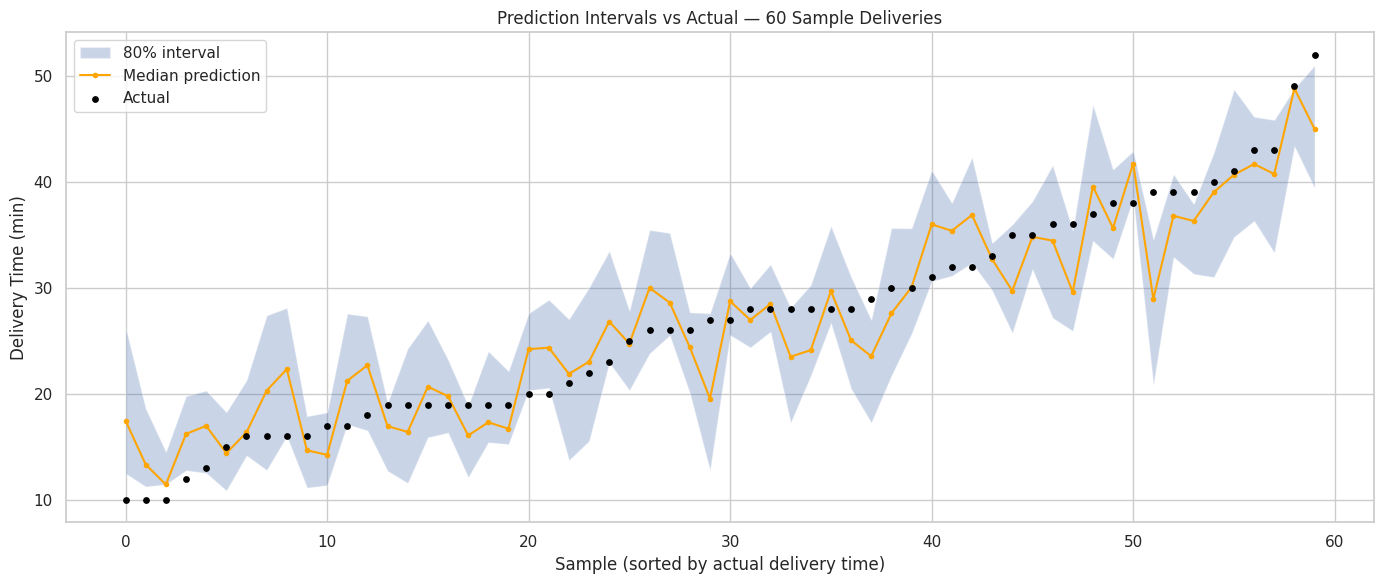

In [24]:
sample = val_df.sample(60, random_state=RANDOM_SEED).sort_values(target_col).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(range(len(sample)), sample["pred_lower"], sample["pred_upper"], alpha=0.3, label="80% interval")
ax.plot(range(len(sample)), sample["pred_median"], "o-", markersize=3, label="Median prediction", color="orange")
ax.scatter(range(len(sample)), sample[target_col], color="black", s=15, label="Actual", zorder=5)
ax.set_xlabel("Sample (sorted by actual delivery time)")
ax.set_ylabel("Delivery Time (min)")
ax.set_title("Prediction Intervals vs Actual — 60 Sample Deliveries")
ax.legend()
plt.tight_layout()
plt.show()

In [25]:
for seg_col in ["Road_traffic_density", "Weather_conditions"]:
    print(f"--- Coverage by {seg_col} ---")
    print(val_df.groupby(seg_col, observed=True)["within_interval"].mean().mul(100).round(1))
    print()

--- Coverage by Road_traffic_density ---
Road_traffic_density
High      70.8
Jam       71.2
Low       71.1
Medium    73.7
Name: within_interval, dtype: float64

--- Coverage by Weather_conditions ---
Weather_conditions
Cloudy        70.8
Fog           73.1
Sandstorms    71.8
Stormy        73.8
Sunny         69.3
Windy         71.3
Name: within_interval, dtype: float64



## Calibrating the Intervals — Conformalized Quantile Regression (CQR)

Raw quantile intervals under-cover (71.8% vs 80% target) uniformly across segments — the
regularization tuned for point-prediction MAE is over-shrinking the tail quantiles. Standard fix:
measure the miscalibration on val (never used for fitting), apply a fixed correction margin, then
verify genuine coverage on test — the first legitimate touch of the test set, reserved for exactly
this kind of final verification per Section 20.

In [26]:
alpha = 0.20  # for an 80% interval (10th-90th percentile)

# Non-conformity score: how far outside the interval each true value falls (0 or negative if inside)
conformity_scores = np.maximum(
    val_df["pred_lower"] - val_df[target_col],
    val_df[target_col] - val_df["pred_upper"]
)

# Correction margin: the (1-alpha) quantile of how far actuals fell outside the raw interval
n = len(val_df)
q_level = np.ceil((n + 1) * (1 - alpha)) / n
correction_margin = np.quantile(conformity_scores, q_level)

print(f"Conformal correction margin: {correction_margin:.3f} minutes")
print(f"(This gets added to pred_upper and subtracted from pred_lower)")

Conformal correction margin: 0.533 minutes
(This gets added to pred_upper and subtracted from pred_lower)


In [27]:
val_df["pred_lower_calibrated"] = val_df["pred_lower"] - correction_margin
val_df["pred_upper_calibrated"] = val_df["pred_upper"] + correction_margin

val_df["within_interval_calibrated"] = (
    (val_df[target_col] >= val_df["pred_lower_calibrated"]) &
    (val_df[target_col] <= val_df["pred_upper_calibrated"])
)

print(f"Calibrated coverage on val (expected ~80% by construction): {val_df['within_interval_calibrated'].mean()*100:.1f}%")
print(f"Calibrated average width: {(val_df['pred_upper_calibrated'] - val_df['pred_lower_calibrated']).mean():.2f} min (was {avg_width:.2f})")

Calibrated coverage on val (expected ~80% by construction): 80.0%
Calibrated average width: 10.25 min (was 9.18)


In [28]:
test_df["pred_lower"] = quantile_models["lower_10"].predict(X_test)
test_df["pred_median"] = quantile_models["median_50"].predict(X_test)
test_df["pred_upper"] = quantile_models["upper_90"].predict(X_test)

test_df["pred_lower_calibrated"] = test_df["pred_lower"] - correction_margin
test_df["pred_upper_calibrated"] = test_df["pred_upper"] + correction_margin

test_df["within_interval_calibrated"] = (
    (test_df[target_col] >= test_df["pred_lower_calibrated"]) &
    (test_df[target_col] <= test_df["pred_upper_calibrated"])
)

test_coverage = test_df["within_interval_calibrated"].mean() * 100
test_avg_width = (test_df["pred_upper_calibrated"] - test_df["pred_lower_calibrated"]).mean()

print(f"TEST SET coverage (genuine, unseen data): {test_coverage:.1f}%")
print(f"TEST SET average interval width: {test_avg_width:.2f} minutes")

TEST SET coverage (genuine, unseen data): 79.9%
TEST SET average interval width: 10.21 minutes


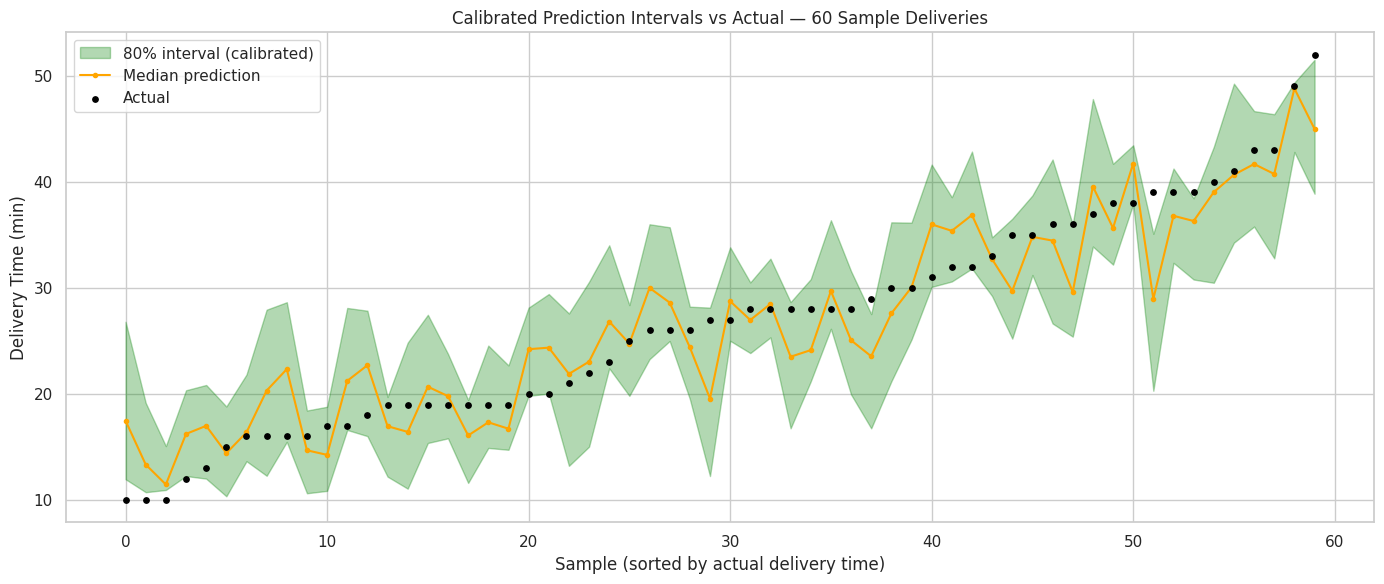

In [29]:
sample = val_df.sample(60, random_state=RANDOM_SEED).sort_values(target_col).reset_index()

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(range(len(sample)), sample["pred_lower_calibrated"], sample["pred_upper_calibrated"],
                 alpha=0.3, label="80% interval (calibrated)", color="green")
ax.plot(range(len(sample)), sample["pred_median"], "o-", markersize=3, label="Median prediction", color="orange")
ax.scatter(range(len(sample)), sample[target_col], color="black", s=15, label="Actual", zorder=5)
ax.set_xlabel("Sample (sorted by actual delivery time)")
ax.set_ylabel("Delivery Time (min)")
ax.set_title("Calibrated Prediction Intervals vs Actual — 60 Sample Deliveries")
ax.legend()
plt.tight_layout()
plt.show()

## predict_delivery() — Individual Prediction Explanation

Combines the final model (XGBoost), calibrated quantile models, and SHAP into one function,
per plan Section 21.

In [30]:
def predict_delivery(order: dict, top_n_factors: int = 3):
    """
    order: dict of raw feature values matching the training schema (single delivery).
    Returns point estimate, calibrated 80% interval, and top SHAP factors in each direction.
    """
    order_df = pd.DataFrame([order])

    point_pred = xgb_model.predict(order_df)[0]
    lower = quantile_models["lower_10"].predict(order_df)[0] - correction_margin
    upper = quantile_models["upper_90"].predict(order_df)[0] + correction_margin

    order_transformed = xgb_model.named_steps["preprocess"].transform(order_df)
    shap_vals = explainer_xgb.shap_values(order_transformed)[0]
    shap_series = pd.Series(shap_vals, index=xgb_feature_names).sort_values()

    factors_decreasing = shap_series.head(top_n_factors)
    factors_increasing = shap_series.tail(top_n_factors)[::-1]

    return {
        "predicted_minutes": round(float(point_pred), 1),
        "interval_minutes": (round(float(lower), 1), round(float(upper), 1)),
        "factors_increasing": [(name, round(float(val), 2)) for name, val in factors_increasing.items()],
        "factors_decreasing": [(name, round(float(val), 2)) for name, val in factors_decreasing.items()],
    }


# Test on one real validation row
sample_order = X_val.iloc[0][feature_metadata["feature_cols"]].to_dict()
result = predict_delivery(sample_order)

print(f"Predicted delivery time: {result['predicted_minutes']} minutes")
print(f"Prediction interval: {result['interval_minutes'][0]}–{result['interval_minutes'][1]} minutes")
print(f"\nFactors increasing expected time:")
for name, val in result["factors_increasing"]:
    print(f"  + {name}: {val:+.2f}")
print(f"\nFactors decreasing expected time:")
for name, val in result["factors_decreasing"]:
    print(f"  - {name}: {val:+.2f}")
print(f"\nActual delivery time was: {y_val.iloc[0]} minutes")

Predicted delivery time: 45.0 minutes
Prediction interval: 41.1–46.7 minutes

Factors increasing expected time:
  + num__multiple_deliveries: +10.32
  + num__Delivery_person_Ratings: +2.51
  + cat__Road_traffic_density_Low: +1.56

Factors decreasing expected time:
  - num__Vehicle_condition: -0.79
  - cat__Weather_conditions_Cloudy: -0.20
  - num__order_day_of_week: -0.11

Actual delivery time was: 46 minutes


## Temporal Generalization Experiment (Section 22)

Compare the model trained/evaluated on the random split (what we've used throughout) against the
same architecture trained/evaluated on the time-based split (earlier orders -> train, later -> test).
Tests whether performance holds up on genuinely future, unseen time periods.

In [31]:
train_temporal = df[df["split_temporal"] == "train"]
test_temporal = df[df["split_temporal"] == "test"]

X_train_temporal, y_train_temporal = train_temporal, train_temporal[target_col]
X_test_temporal, y_test_temporal = test_temporal, test_temporal[target_col]

xgb_temporal_pipeline = Pipeline([
    ("preprocess", build_preprocessor(scale_numeric=False)),
    ("model", XGBRegressor(**base_params, random_state=RANDOM_SEED, n_jobs=-1)),
])
xgb_temporal_pipeline.fit(X_train_temporal, y_train_temporal)

temporal_pred = xgb_temporal_pipeline.predict(X_test_temporal)
temporal_metrics = compute_metrics(y_test_temporal, temporal_pred)

# Compare to the same architecture's performance on the random-split test set
random_test_pred = xgb_model.predict(X_test)
random_metrics = compute_metrics(y_test, random_test_pred)

print("Random split (test):")
print(random_metrics)
print("\nTemporal split (test — later, unseen time period):")
print(temporal_metrics)
print(f"\nMAE difference (temporal - random): {temporal_metrics['MAE'] - random_metrics['MAE']:+.3f}")

Random split (test):
{'MAE': 3.172759771347046, 'RMSE': np.float64(4.00608029772328), 'R2': 0.8181862831115723, 'MedAE': np.float64(2.685863494873047), 'within_5min_pct': np.float64(79.96490201813396), 'within_10min_pct': np.float64(98.5083357706932)}

Temporal split (test — later, unseen time period):
{'MAE': 3.775299310684204, 'RMSE': np.float64(4.9253407704149685), 'R2': 0.7316235303878784, 'MedAE': np.float64(3.0761327743530273), 'within_5min_pct': np.float64(73.67651360046797), 'within_10min_pct': np.float64(95.05703422053232)}

MAE difference (temporal - random): +0.603


## Why Does Temporal Performance Drop? Checking Distribution Shift

In [32]:
print("Festival distribution — temporal train vs test:")
print(pd.crosstab(df["split_temporal"], df["Festival"], normalize="index").round(3))

print("\nRoad_traffic_density distribution — temporal train vs test:")
print(pd.crosstab(df["split_temporal"], df["Road_traffic_density"], normalize="index").round(3))

print("\nWeather_conditions distribution — temporal train vs test:")
print(pd.crosstab(df["split_temporal"], df["Weather_conditions"], normalize="index").round(3))

Festival distribution — temporal train vs test:
Festival           No    Yes
split_temporal              
test            0.979  0.021
train           0.980  0.020
val             0.982  0.018

Road_traffic_density distribution — temporal train vs test:
Road_traffic_density   High    Jam    Low  Medium
split_temporal                                   
test                  0.087  0.318  0.346   0.249
train                 0.097  0.312  0.349   0.242
val                   0.116  0.321  0.319   0.245

Weather_conditions distribution — temporal train vs test:
Weather_conditions  Cloudy    Fog  Sandstorms  Stormy  Sunny  Windy
split_temporal                                                     
test                 0.163  0.171       0.174   0.169  0.156  0.167
train                0.168  0.170       0.165   0.170  0.162  0.164
val                  0.168  0.169       0.166   0.164  0.165  0.167


In [33]:
test_temporal_with_pred = test_temporal.copy()
test_temporal_with_pred["pred"] = temporal_pred
test_temporal_with_pred["abs_error"] = (test_temporal_with_pred[target_col] - test_temporal_with_pred["pred"]).abs()

print(test_temporal_with_pred.groupby("Festival")["abs_error"].agg(["mean", "count"]))

              mean  count
Festival                 
No        3.770026   6657
Yes       4.031110    143


In [34]:
import importlib
import explain_utils
importlib.reload(explain_utils)
from explain_utils import predict_delivery

# Wrapper matching our specific fitted objects, so call sites stay simple
def predict_delivery_final(order: dict, top_n_factors: int = 3) -> dict:
    return predict_delivery(
        order, model=xgb_model,
        quantile_models={"lower_10": quantile_models["lower_10"], "upper_90": quantile_models["upper_90"]},
        correction_margin=correction_margin, explainer=explainer_xgb,
        feature_names=xgb_feature_names, top_n_factors=top_n_factors,
    )

# Re-verify it still works through the file
result = predict_delivery_final(sample_order)
print(result)

{'predicted_minutes': 45.0, 'interval_minutes': (41.1, 46.7), 'factors_increasing': [('num__multiple_deliveries', 10.32), ('num__Delivery_person_Ratings', 2.51), ('cat__Road_traffic_density_Low', 1.56)], 'factors_decreasing': [('num__Vehicle_condition', -0.79), ('cat__Weather_conditions_Cloudy', -0.2), ('num__order_day_of_week', -0.11)]}


In [35]:
numeric_check_cols = ["distance_km", "Delivery_person_Age", "Delivery_person_Ratings", "multiple_deliveries"]
print(df.groupby("split_temporal")[numeric_check_cols].mean().round(3))
print()
print(df.groupby("split_temporal")[target_col].mean().round(3))

                distance_km  Delivery_person_Age  Delivery_person_Ratings  \
split_temporal                                                              
test                 10.346               29.572                    4.597   
train                 9.658               29.560                    4.636   
val                   9.375               29.597                    4.642   

                multiple_deliveries  
split_temporal                       
test                          0.749  
train                         0.745  
val                           0.740  

split_temporal
test     26.533
train    26.286
val      26.094
Name: Time_taken (min), dtype: float64


## Temporal Generalization — Conclusion

MAE degrades from 3.173 (random split) to 3.775 (temporal split, +19% relative) when evaluated on
genuinely future, unseen time periods. Ruled out: Festival/traffic/weather distribution shift (all
stable across train/val/test), Festival-day-specific error (only 143 rows, small effect). Identified
cause: distance_km drifts upward ~7% between train (9.66 km) and test (10.35 km) periods, while all
other numeric features remain stable. Since distance is the dominant feature throughout this
analysis, a model calibrated to an earlier, shorter-average-distance period is mildly miscalibrated
for a later period with longer average distances. This demonstrates the value of periodic
retraining/monitoring in a real deployment — a model this accurate on historical data can still
degrade against future data if the underlying distribution shifts, even modestly.

## Error Analysis Case Studies (Section 23)

Best prediction, large overprediction, large underprediction — using the random-split test set
(genuinely held out, first real use of it for anything beyond the coverage check).

In [36]:
test_df["pred"] = xgb_model.predict(X_test)
test_df["error"] = test_df[target_col] - test_df["pred"]  # positive = underprediction
test_df["abs_error"] = test_df["error"].abs()

best_case = test_df.loc[test_df["abs_error"].idxmin()]
overprediction_case = test_df.loc[test_df["error"].idxmin()]  # most negative error = biggest overprediction
underprediction_case = test_df.loc[test_df["error"].idxmax()]  # most positive error = biggest underprediction

print(f"Best prediction: actual={best_case[target_col]}, pred={best_case['pred']:.1f}, error={best_case['error']:.2f}")
print(f"Largest overprediction: actual={overprediction_case[target_col]}, pred={overprediction_case['pred']:.1f}, error={overprediction_case['error']:.2f}")
print(f"Largest underprediction: actual={underprediction_case[target_col]}, pred={underprediction_case['pred']:.1f}, error={underprediction_case['error']:.2f}")

Best prediction: actual=20, pred=20.0, error=0.00
Largest overprediction: actual=16, pred=33.6, error=-17.56
Largest underprediction: actual=53, pred=29.7, error=23.31


In [37]:
def explain_case(row, label):
    order = row[feature_metadata["feature_cols"]].to_dict()
    result = predict_delivery_final(order)

    print(f"=== {label} ===")
    print(f"Actual: {row[target_col]} min | Predicted: {result['predicted_minutes']} min | "
          f"Interval: {result['interval_minutes'][0]}-{result['interval_minutes'][1]} min | "
          f"Error: {row['error']:+.2f} min")
    print(f"\nKey context: distance={row['distance_km']:.1f}km, traffic={row['Road_traffic_density']}, "
          f"weather={row['Weather_conditions']}, festival={row['Festival']}, "
          f"multiple_deliveries={row['multiple_deliveries']}")
    print(f"\nFactors increasing predicted time:")
    for name, val in result["factors_increasing"]:
        print(f"  + {name}: {val:+.2f}")
    print(f"\nFactors decreasing predicted time:")
    for name, val in result["factors_decreasing"]:
        print(f"  - {name}: {val:+.2f}")
    print()

explain_case(best_case, "Best Prediction")
explain_case(overprediction_case, "Largest Overprediction")
explain_case(underprediction_case, "Largest Underprediction")

=== Best Prediction ===
Actual: 20 min | Predicted: 20.0 min | Interval: 15.3-23.5 min | Error: +0.00 min

Key context: distance=13.6km, traffic=Low, weather=Windy, festival=No, multiple_deliveries=1.0

Factors increasing predicted time:
  + num__Vehicle_condition: +2.78
  + num__distance_km: +1.23
  + city__City_Metropolitian: +0.18

Factors decreasing predicted time:
  - cat__Road_traffic_density_Low: -4.13
  - num__Delivery_person_Age: -2.69
  - num__Delivery_person_Ratings: -1.58

=== Largest Overprediction ===
Actual: 16 min | Predicted: 33.6 min | Interval: 17.0-40.9 min | Error: -17.56 min

Key context: distance=19.9km, traffic=None, weather=None, festival=No, multiple_deliveries=1.0

Factors increasing predicted time:
  + num__distance_km: +3.88
  + num__Delivery_person_Age: +2.34
  + cat__Road_traffic_density_Low: +1.54

Factors decreasing predicted time:
  - num__Delivery_person_Ratings: -1.41
  - num__Vehicle_condition: -0.99
  - cat__Weather_conditions_Cloudy: -0.61

=== La

In [38]:
test_df["traffic_and_weather_missing"] = test_df["Road_traffic_density"].isna() & test_df["Weather_conditions"].isna()

print(test_df.groupby("traffic_and_weather_missing")["abs_error"].agg(["mean", "median", "count"]))

# Also check each missing individually, for comparison
test_df["traffic_missing"] = test_df["Road_traffic_density"].isna()
test_df["weather_missing"] = test_df["Weather_conditions"].isna()
print("\nTraffic missing alone:")
print(test_df.groupby("traffic_missing")["abs_error"].agg(["mean", "count"]))
print("\nWeather missing alone:")
print(test_df.groupby("weather_missing")["abs_error"].agg(["mean", "count"]))

                                 mean    median  count
traffic_and_weather_missing                           
False                        3.140764  2.668051   6740
True                         5.373349  4.311079     98

Traffic missing alone:
                     mean  count
traffic_missing                 
False            3.140764   6740
True             5.373349     98

Weather missing alone:
                     mean  count
weather_missing                 
False            3.140027   6736
True             5.334423    102


## Case Studies — Summary

- **Best prediction**: exact match (20.0 vs 20 actual) — no report-worthy explanation needed,
  included to show the system working as intended.
- **Largest overprediction** (-17.6 min): both Road_traffic_density AND Weather_conditions missing
  simultaneously — our two strongest predictors both unavailable. Confirmed NOT a coincidence:
  rows with both missing show 71% higher mean absolute error (5.37 vs 3.14 min, n=98) than the rest
  of the test set. Further finding: these two features are missing together almost every time
  (98 traffic-missing rows vs 102 weather-missing rows) — suggesting a shared root cause (e.g. a
  batch of orders with no live-conditions data captured at all) rather than independent random gaps.
  **Limitation for the README**: model reliability degrades meaningfully when both traffic and
  weather are unavailable at prediction time.
- **Largest underprediction** (+23.3 min): 6.1km delivery taking 53 minutes under High traffic —
  all key features present and correctly factored in (Sunny weather correctly pushed prediction
  down), yet the actual pace (~8.7 min/km) is extreme with no identifiable cause in available
  features. Likely an inherent outlier, possibly linked to the synthetic/templated character of
  this dataset noted in notebook 1 (recall the quantized prep_time_min) — reported honestly as
  "no identifiable cause," not explained away.

In [39]:
import pickle
import json

with open(f"{DRIVE_OUTPUT_DIR}/models/final_model_xgboost.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

with open(f"{DRIVE_OUTPUT_DIR}/models/quantile_models.pkl", "wb") as f:
    pickle.dump(quantile_models, f)

final_metadata = {
    "final_model": "XGBoost (tuned)",
    "final_model_selection_reason": "Essentially tied with HistGB on every diagnostic (val MAE, "
        "residuals, error segmentation — mean segment MAE diff 0.034 min). Chosen on practical "
        "grounds: marginally better MAE, more mature SHAP/deployment tooling.",
    "test_mae_random_split": float(random_metrics["MAE"]),
    "test_mae_temporal_split": float(temporal_metrics["MAE"]),
    "temporal_degradation_cause": "distance_km drifts ~7% higher (9.66km train mean -> 10.35km "
        "test mean) between earlier and later time periods; all other numeric features stable.",
    "conformal_correction_margin": float(correction_margin),
    "test_coverage_calibrated": float(test_coverage),
    "test_avg_interval_width": float(test_avg_width),
    "compound_missingness_finding": "Rows missing BOTH Road_traffic_density and Weather_conditions "
        "(n=98, nearly identical to traffic-missing-alone count) show 71% higher mean abs error "
        "(5.37 vs 3.14 min) than the rest of the test set. The two features are missing together "
        "almost every time, suggesting a shared root cause rather than independent gaps.",
}
with open(f"{DRIVE_OUTPUT_DIR}/final_model_metadata.json", "w") as f:
    json.dump(final_metadata, f, indent=2)

print("Notebook 3 complete — final model, quantile models, and metadata saved to Drive.")

Notebook 3 complete — final model, quantile models, and metadata saved to Drive.
